# 10kGNAD - A german topic classification dataset.


## 1. imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Dataset

### 2.1 Datasets loading

In [2]:
columns = ["label", "text", "publishingDate"]
train_df = pd.read_csv(
    "/home/michaelschlee/ownCloud/GIT/LabelFusion/Dataset_Descriptives/data/10kGNAD/train.csv",
    sep=';',
    quotechar="'",
    header=None,
    names=columns,
)
test_df = pd.read_csv(
    "/home/michaelschlee/ownCloud/GIT/LabelFusion/Dataset_Descriptives/data/10kGNAD/test.csv",
    sep=';',
    quotechar="'",
    header=None,
    names=columns,
)

In [3]:
train_df

,label,text,publishingDate
0,Sport,21-Jähriger fällt wohl bis Saisonende aus. Wie...,2016-03-17 23:11:28.00
1,Kultur,"Erfundene Bilder zu Filmen, die als verloren g...",2016-03-31 05:30:00.00
2,Web,Der frischgekürte CEO Sundar Pichai setzt auf ...,2015-10-24 09:22:17.00
3,Wirtschaft,"Putin: ""Einigung, dass wir Menge auf Niveau vo...",2016-03-02 15:04:00.00
4,Inland,Estland sieht den künftigen österreichischen P...,2016-05-24 07:17:56.00
...,...,...,...
9240,Inland,Bernd Saurer war Bridge-Juniorenweltmeister un...,2015-11-11 12:56:37.88
9241,International,Sandhere soll in vergangener Woche bei Luftang...,2015-12-08 09:24:27.00
9242,Wirtschaft,Derzeit Konzeptgruppe in Berlin – Kein Komment...,2016-04-18 10:39:08.00
9243,Inland,Landeshauptmann will den vierten Regierungssit...,2015-10-12 15:07:11.00


In [4]:
test_df

,label,text,publishingDate
0,Wirtschaft,"Die Gewerkschaft GPA-djp lanciert den ""All-in-...",2016-02-01 13:03:44.00
1,Sport,Franzosen verteidigen 2:1-Führung – Kritische ...,2016-03-08 21:22:33.00
2,Web,Neues Video von Designern macht im Netz die Ru...,2016-05-15 12:23:16.00
3,Sport,23-jähriger Brasilianer muss vier Spiele pausi...,2015-06-20 09:11:47.00
4,International,Aufständische verwendeten Chemikalie bei Gefec...,2015-11-05 21:09:03.00
...,...,...,...
1023,Web,"Programm ""Ebay Plus"" soll Ende September start...",2015-09-11 14:43:10.00
1024,Inland,"Fehlerhafte Bilanz 2013, Partei will berufen –...",2015-11-10 11:32:01.00
1025,Sport,Als erster Olympia-Champion auch Hawaii-Sieger...,2015-10-11 13:52:57.00
1026,Sport,Der Außenseiter aus Denver gewinnt die 50. Sup...,2016-02-08 04:48:30.00


### 2.1 Descriptives

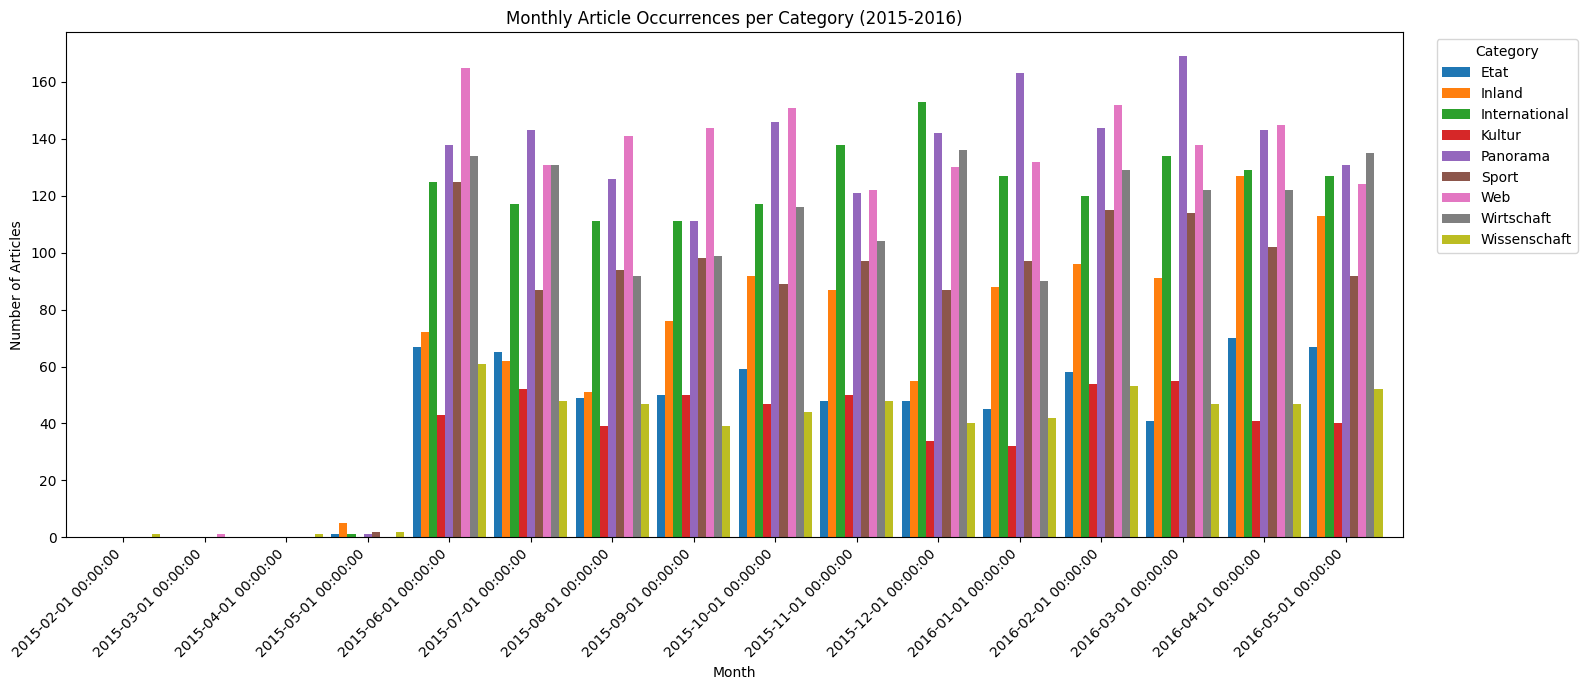

label,Etat,Inland,International,Kultur,Panorama,Sport,Web,Wirtschaft,Wissenschaft
month,,,,,,,,,
2015-02-01,0,0,0,0,0,0,0,0,1
2015-03-01,0,0,0,0,0,0,1,0,0
2015-04-01,0,0,0,0,0,0,0,0,1
2015-05-01,1,5,1,0,1,2,0,0,2
2015-06-01,67,72,125,43,138,125,165,134,61
2015-07-01,65,62,117,52,143,87,131,131,48
2015-08-01,49,51,111,39,126,94,141,92,47
2015-09-01,50,76,111,50,111,98,144,99,39
2015-10-01,59,92,117,47,146,89,151,116,44


In [5]:
df_cat = pd.concat([train_df, test_df], ignore_index=True).copy()
df_cat["publishingDate"] = pd.to_datetime(df_cat["publishingDate"], errors="coerce")
df_cat = df_cat.dropna(subset=["publishingDate", "label"])

# Focus on 2015-2016 to keep the chart readable.
df_cat = df_cat[df_cat["publishingDate"].dt.year.isin([2015, 2016])]
df_cat["month"] = df_cat["publishingDate"].dt.to_period("M").dt.to_timestamp()

month_cat_counts = (
    df_cat.groupby(["month", "label"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

ax = month_cat_counts.plot(kind="bar", figsize=(16, 7), width=0.9)
ax.set_title("Monthly Article Occurrences per Category (2015-2016)")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Articles")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

month_cat_counts

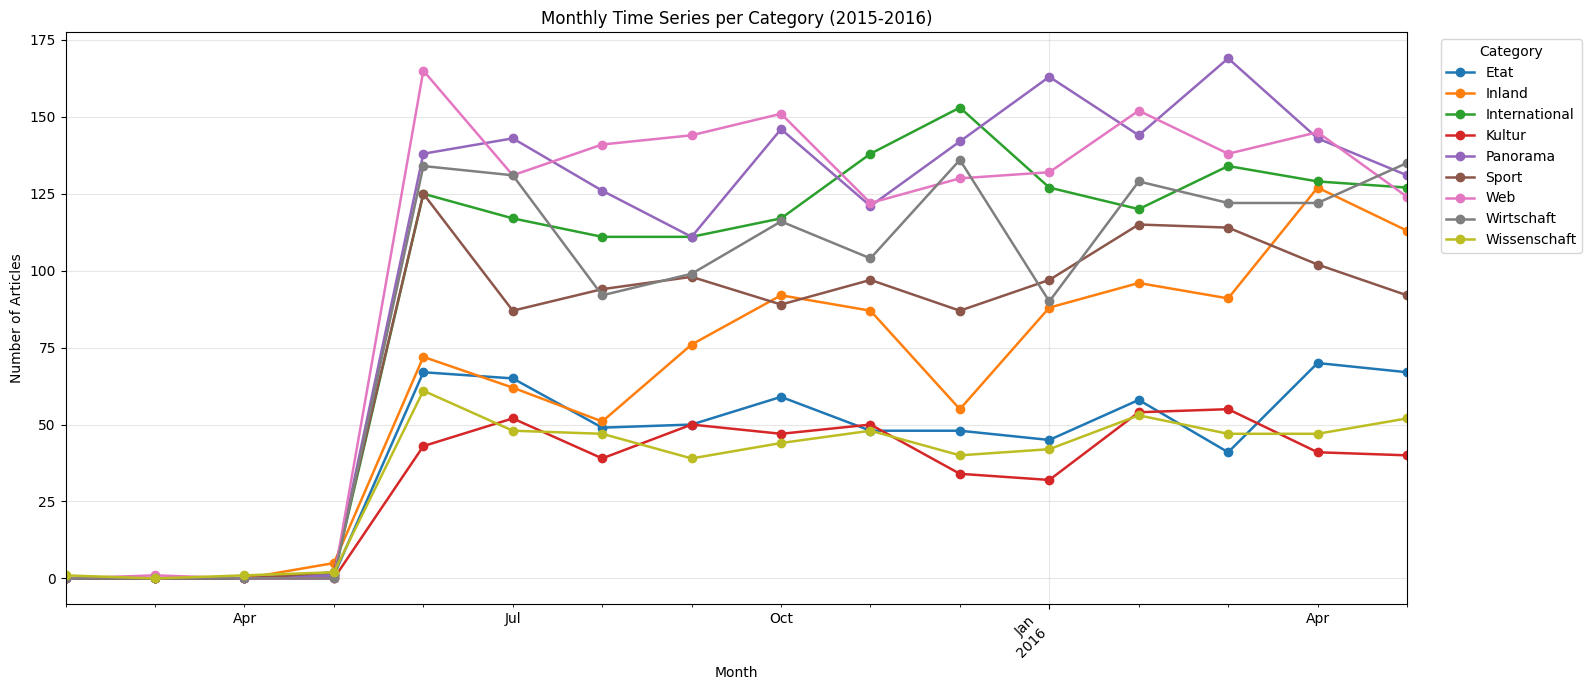

label,Etat,Inland,International,Kultur,Panorama,Sport,Web,Wirtschaft,Wissenschaft
month,,,,,,,,,
2015-02-01,0,0,0,0,0,0,0,0,1
2015-03-01,0,0,0,0,0,0,1,0,0
2015-04-01,0,0,0,0,0,0,0,0,1
2015-05-01,1,5,1,0,1,2,0,0,2
2015-06-01,67,72,125,43,138,125,165,134,61
2015-07-01,65,62,117,52,143,87,131,131,48
2015-08-01,49,51,111,39,126,94,141,92,47
2015-09-01,50,76,111,50,111,98,144,99,39
2015-10-01,59,92,117,47,146,89,151,116,44


In [6]:
# Monthly time series per category
ax = month_cat_counts.plot(kind="line", figsize=(16, 7), marker="o", linewidth=1.8)
ax.set_title("Monthly Time Series per Category (2015-2016)")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Articles")
plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.3)
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

month_cat_counts

### 2.1 Ordered printing of texts

In [7]:
from pathlib import Path

# Combine train and test so all available texts are included.
all_texts_df = pd.concat([train_df, test_df], ignore_index=True)
all_texts_df = all_texts_df.dropna(subset=["label", "text"])

output_path = Path("/home/michaelschlee/ownCloud/GIT/LabelFusion/Dataset_Descriptives/data/10kGNAD/texts_grouped_by_category.txt")

with output_path.open("w", encoding="utf-8") as f:
    for category in sorted(all_texts_df["label"].unique()):
        f.write(f"=== {category} ===\n\n")
        category_texts = all_texts_df.loc[all_texts_df["label"] == category, "text"]
        for text in category_texts:
            f.write(str(text).strip())
            f.write("\n\n")

print(f"Created: {output_path}")

Created: /home/michaelschlee/ownCloud/GIT/LabelFusion/Dataset_Descriptives/data/10kGNAD/texts_grouped_by_category.txt


## 3. Retrieving time series for each category

### 3.1 Etat

In [8]:
"""
Fetch Google Trends (weekly) for Austrian media brands — 2014–2016.
Adds retry + exponential backoff to handle Google 429 rate limits.
"""

from pytrends.request import TrendReq
from pytrends.exceptions import TooManyRequestsError
import pandas as pd
import time
import random

TIMEFRAME = "2014-01-01 2016-12-31"
GEO = "AT"

# Do not pass retries/backoff_factor here; older pytrends versions break with newer urllib3.
pytrends = TrendReq(hl="de-AT", tz=60)

def fetch_interest_over_time(keywords, max_retries=7, base_sleep=15):
    """Build payload and fetch interest_over_time with exponential backoff on 429."""
    for attempt in range(1, max_retries + 1):
        try:
            pytrends.build_payload(keywords, timeframe=TIMEFRAME, geo=GEO)
            df = pytrends.interest_over_time().drop(columns=["isPartial"], errors="ignore")
            if df.empty:
                raise ValueError(f"Empty result for keywords: {keywords}")
            return df
        except TooManyRequestsError:
            wait = base_sleep * (2 ** (attempt - 1)) + random.uniform(1, 4)
            print(f"429 for {keywords} (attempt {attempt}/{max_retries}) -> waiting {wait:.1f}s")
            time.sleep(wait)
    raise RuntimeError(
        "Google Trends kept returning 429 after retries. Wait 30-60 minutes and rerun this cell."
    )

# --- Batch 1 (anchor: ORF) ---
batch1 = ["ORF", "Der Standard", "Kronen Zeitung", "Kurier", "Die Presse"]
df1 = fetch_interest_over_time(batch1)
print("Batch 1 fetched:", df1.shape)
time.sleep(random.uniform(8, 12))

# --- Batch 2 (ORF repeated as anchor) ---
batch2 = ["ORF", "Profil", "Kleine Zeitung", "Heute", "Österreich"]
df2 = fetch_interest_over_time(batch2)
print("Batch 2 fetched:", df2.shape)
time.sleep(random.uniform(8, 12))

# --- Batch 3 ---
batch3 = ["ORF", "News Magazin", "format magazin", "derstandard.at", "krone.at"]
df3 = fetch_interest_over_time(batch3)
print("Batch 3 fetched:", df3.shape)

# --- Rescale batches 2 & 3 to batch 1's ORF scale ---
def rescale(df_anchor_col, df_target, anchor_name="ORF"):
    """Scale df_target so its anchor column matches df_anchor_col."""
    ratio = df_anchor_col.mean() / df_target[anchor_name].mean()
    scaled = df_target.drop(columns=[anchor_name]) * ratio
    return scaled.clip(0, 100)

df2_scaled = rescale(df1["ORF"], df2)
df3_scaled = rescale(df1["ORF"], df3)

# --- Combine ---
combined = pd.concat([df1, df2_scaled, df3_scaled], axis=1)
combined.index.name = "week"
combined.columns = [
    c.replace(" Magazin", "").replace("format magazin", "Format")
    for c in combined.columns
]

print("\nCombined shape:", combined.shape)
print(combined.head())

# --- Save ---
combined.to_csv("austria_media_trends_weekly.csv")
combined.to_excel("austria_media_trends_weekly.xlsx")
print("\nSaved: austria_media_trends_weekly.csv / .xlsx")

# --- Quick summary ---
print("\nMean weekly interest (0-100 scale, AT):")
print(combined.mean().sort_values(ascending=False).round(1))

Batch 1 fetched: (157, 5)
Batch 2 fetched: (157, 5)
Batch 3 fetched: (157, 5)

Combined shape: (157, 13)
            ORF  Der Standard  Kronen Zeitung  Kurier  Die Presse    Profil  \
week                                                                          
2013-12-29   63             4               3       6           2  1.188217   
2014-01-05   54             4               3       5           2  1.188217   
2014-01-12   53             4               3       6           2  1.188217   
2014-01-19   60             4               3       6           2  1.188217   
2014-01-26   59             4               3       6           2  1.188217   

            Kleine Zeitung      Heute  Österreich  News  Format  \
week                                                              
2013-12-29        9.505737  17.823256   74.857677   0.0     0.0   
2014-01-05       10.693954  15.446822   86.739848   0.0     0.0   
2014-01-12        8.317520  14.258605   90.304499   0.0     0.0   
2014-0

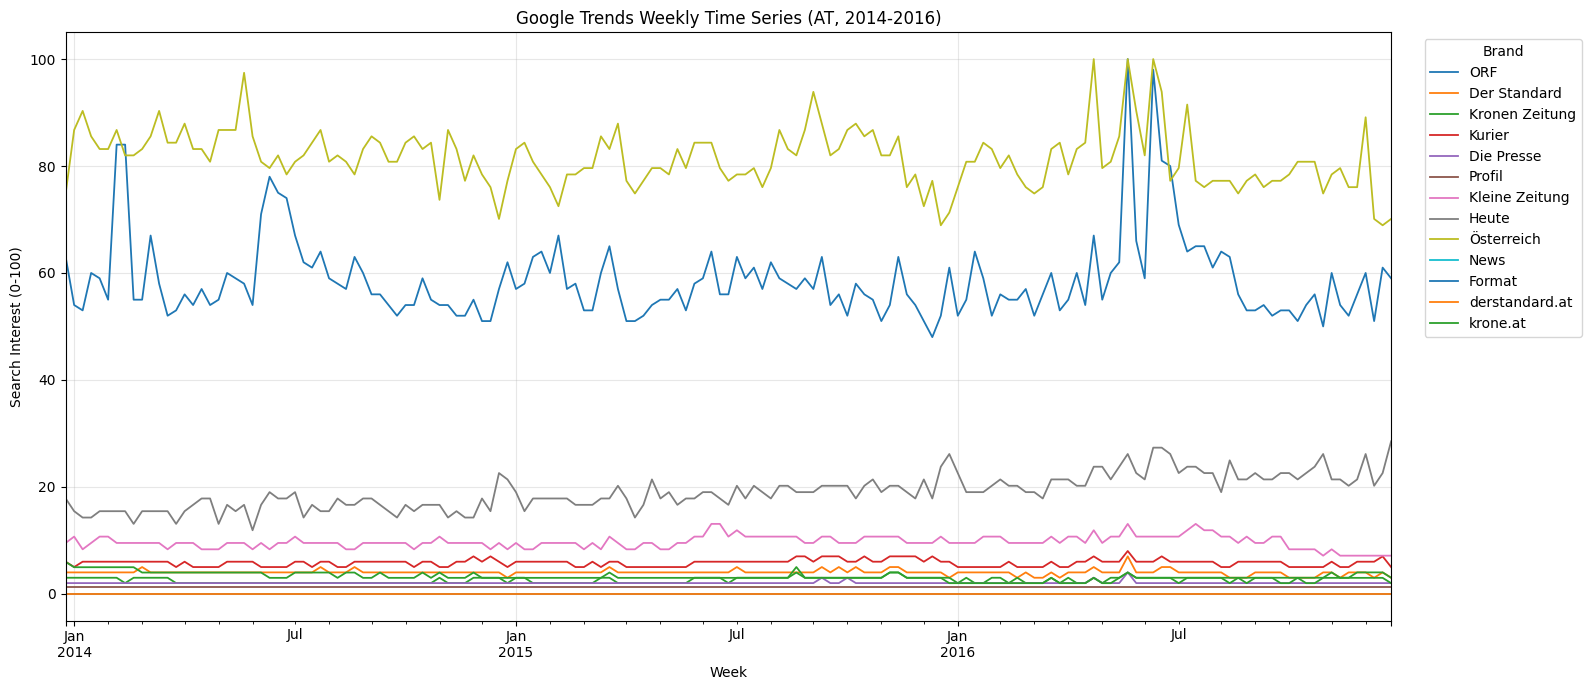

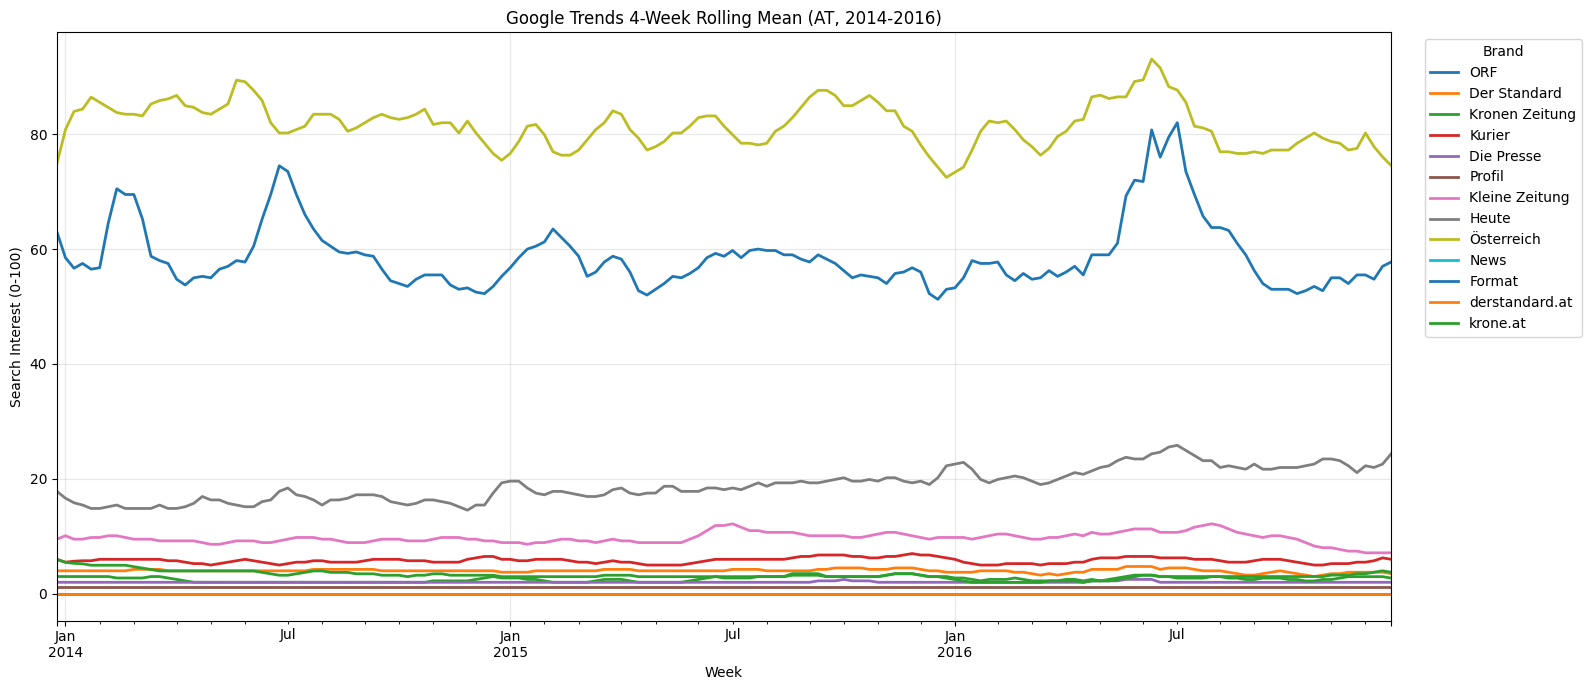

In [9]:
import matplotlib.pyplot as plt

# Weekly Google Trends time series for all brands
ax = combined.plot(figsize=(16, 7), linewidth=1.3)
ax.set_title("Google Trends Weekly Time Series (AT, 2014-2016)")
ax.set_xlabel("Week")
ax.set_ylabel("Search Interest (0-100)")
plt.legend(title="Brand", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4-week rolling mean to make trends easier to compare
ax = combined.rolling(4, min_periods=1).mean().plot(figsize=(16, 7), linewidth=2)
ax.set_title("Google Trends 4-Week Rolling Mean (AT, 2014-2016)")
ax.set_xlabel("Week")
ax.set_ylabel("Search Interest (0-100)")
plt.legend(title="Brand", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Inland

In [10]:
"""
Fetch Austrian party poll numbers from Wikipedia opinion polling pages.
Covers the election cycles relevant to the Der Standard corpus (2013–2017).

Install: pip install requests beautifulsoup4 pandas openpyxl lxml

Output:
  austria_polls.csv   — one row per poll, columns: date, pollster, client,
                        SPÖ, ÖVP, FPÖ, Grüne, NEOS, Others
  austria_polls.xlsx  — same, formatted as Excel
"""

import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
from datetime import datetime

URLS = {
    "2017": "https://en.wikipedia.org/wiki/Opinion_polling_for_the_Austrian_legislative_election,_2017",
    "2019": "https://en.wikipedia.org/wiki/Opinion_polling_for_the_2019_Austrian_legislative_election",
}

PARTIES = ["SPÖ", "ÖVP", "FPÖ", "Grüne", "NEOS"]

def clean_num(val):
    """Convert a table cell to float, return None if not a number."""
    val = val.strip().replace(",", ".")
    val = re.sub(r"\[.*?\]", "", val)   # remove footnotes like [a]
    val = re.sub(r"–|—|-", "", val)     # dashes → empty
    try:
        return float(val)
    except ValueError:
        return None

def parse_date(s):
    """Try to parse date string in various formats."""
    s = s.strip()
    for fmt in ("%Y-%m-%d", "%d %B %Y", "%B %d, %Y", "%d/%m/%Y"):
        try:
            return datetime.strptime(s, fmt).date()
        except ValueError:
            continue
    return None

def scrape_polls(url, cycle_label):
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"}
    resp = requests.get(url, headers=headers, timeout=20)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, "lxml")

    rows_out = []
    tables = soup.find_all("table", class_="wikitable")

    for table in tables:
        headers_row = table.find("tr")
        if not headers_row:
            continue
        ths = [th.get_text(strip=True) for th in headers_row.find_all(["th", "td"])]

        # Find column indices for the parties we want
        col_map = {}
        for party in PARTIES:
            for i, h in enumerate(ths):
                if party in h:
                    col_map[party] = i
                    break

        if len(col_map) < 3:
            continue  # not a polling table

        # Find pollster and date columns
        date_col = next((i for i, h in enumerate(ths) if "date" in h.lower() or "end" in h.lower()), 1)
        firm_col = 0

        for row in table.find_all("tr")[1:]:
            cells = row.find_all(["td", "th"])
            if len(cells) < 4:
                continue

            texts = [c.get_text(strip=True) for c in cells]

            # Skip event rows (only one non-empty cell or clearly a header)
            non_empty = [t for t in texts if t]
            if len(non_empty) <= 2:
                continue

            # Extract date
            date_str = texts[date_col] if date_col < len(texts) else ""
            date = parse_date(date_str)
            if date is None:
                # Try reading a YYYY-MM-DD anywhere in the row
                for t in texts:
                    date = parse_date(t)
                    if date:
                        break
            if date is None:
                continue

            # Extract pollster (first cell, often contains firm/client)
            firm_text = texts[firm_col] if texts else ""
            # Split pollster / client on "/" if present
            if "/" in firm_text:
                parts = firm_text.split("/", 1)
                pollster = parts[0].strip()
                client   = parts[1].strip()
            else:
                pollster = firm_text
                client   = ""

            # Extract party numbers
            row_data = {"date": date, "pollster": pollster, "client": client, "cycle": cycle_label}
            for party, col_idx in col_map.items():
                val = clean_num(texts[col_idx]) if col_idx < len(texts) else None
                row_data[party] = val

            # Skip rows where all parties are None (likely event rows)
            if all(row_data.get(p) is None for p in PARTIES):
                continue

            rows_out.append(row_data)

    return rows_out

# ── Main ──────────────────────────────────────────────────────────────────────
all_rows = []
for cycle, url in URLS.items():
    print(f"Scraping {cycle} cycle...")
    try:
        rows = scrape_polls(url, cycle)
        print(f"  → {len(rows)} polls found")
        all_rows.extend(rows)
    except Exception as e:
        print(f"  ERROR: {e}")

df = pd.DataFrame(all_rows)
df = df.sort_values("date").drop_duplicates(subset=["date", "pollster", "SPÖ", "ÖVP", "FPÖ"])
df = df.reset_index(drop=True)

# Filter to historical window 2003–2019
df["date"] = pd.to_datetime(df["date"])
df = df[(df["date"] >= "2003-01-01") & (df["date"] <= "2019-12-31")]

print(f"\nTotal polls after deduplication: {len(df)}")
print(df[["date","pollster","client","SPÖ","ÖVP","FPÖ","Grüne","NEOS"]].head(10).to_string(index=False))

# ── Save ──────────────────────────────────────────────────────────────────────
df.to_csv("austria_polls.csv", index=False)
df.to_excel("austria_polls.xlsx", index=False)
print("\nSaved: austria_polls.csv / austria_polls.xlsx")

# ── Quick summary ─────────────────────────────────────────────────────────────
print("\nPollster frequency:")
print(df["pollster"].value_counts().head(10))

print("\nDate range:", df["date"].min().date(), "→", df["date"].max().date())
print("Polls per year:")
print(df.groupby(df["date"].dt.year).size())

Scraping 2017 cycle...
  → 253 polls found
Scraping 2019 cycle...
  → 0 polls found

Total polls after deduplication: 250
      date                  pollster       client  SPÖ  ÖVP  FPÖ  Grüne  NEOS
2013-09-29 2013 legislative election              26.8 24.0 20.5   12.4   5.0
2013-10-03                    Gallup   Österreich 28.0 23.0 21.0   13.0   7.0
2013-10-17                    Gallup   Österreich 28.0 23.0 22.0   13.0   8.0
2013-10-20                    Market Der Standard 25.0 23.0 25.0   12.0   7.0
2013-10-25                    Gallup   Österreich 27.0 24.0 22.0   13.0   8.0
2013-10-26                  Karmasin       profil 26.0 23.0 23.0   12.0   8.0
2013-10-27                    Market Der Standard 25.0 23.0 24.0   12.0   8.0
2013-11-08                  Karmasin        Heute 27.0 23.0 22.0   12.0   9.0
2013-11-16                    Gallup   Österreich 26.0 23.0 23.0   14.0   9.0
2013-11-23                  Karmasin       profil 26.0 23.0 23.0   14.0   9.0

Saved: austria_poll

Removed 3 invalid rows
Clean data shape: (247, 9)


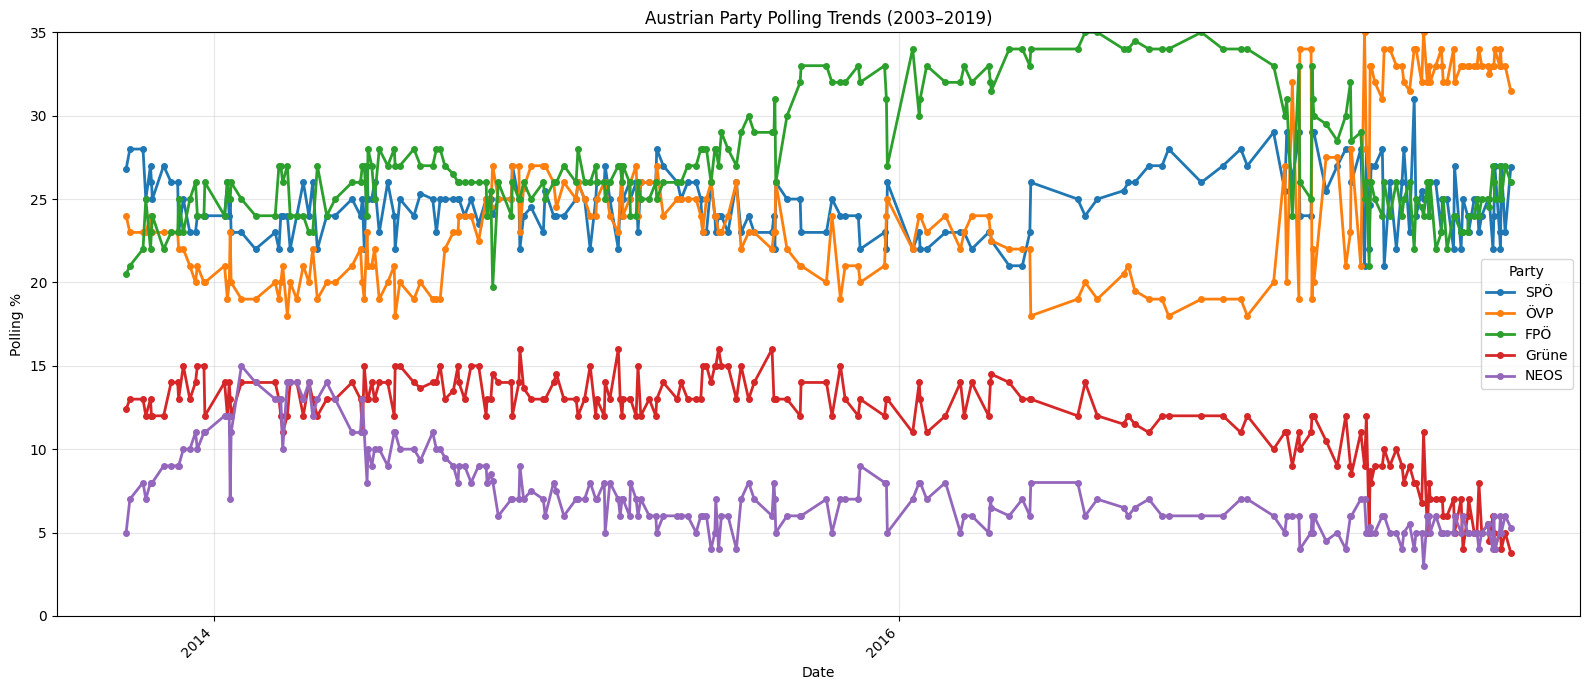

In [11]:
# Filter out invalid rows where any party value exceeds 100%
df_clean = df.copy()
for party in PARTIES:
    df_clean = df_clean[df_clean[party] <= 100]

print(f"Removed {len(df) - len(df_clean)} invalid rows")
print(f"Clean data shape: {df_clean.shape}")

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Time series plot of party polling over 2013–2017
fig, ax = plt.subplots(figsize=(16, 7))

for party in PARTIES:
    party_data = df_clean.groupby("date")[party].mean().dropna()
    ax.plot(party_data.index, party_data.values, marker="o", markersize=4, linewidth=2, label=party)

ax.set_title("Austrian Party Polling Trends (2003–2019)")
ax.set_xlabel("Date")
ax.set_ylabel("Polling %")
ax.xaxis.set_major_locator(mdates.YearLocator(2))  # Every 2 years for clarity
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylim(0, 35)  # Reasonable polling range
plt.xticks(rotation=45, ha="right")
plt.legend(title="Party", loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 3.3 International

#### 3.3.1 Austrian monthly Asylum

In [12]:
"""
Load Austrian monthly asylum application statistics from local Eurostat TSV dump.

Input:
    /home/michaelschlee/ownCloud/GIT/LabelFusion/Dataset_Descriptives/data/migr_asyappctzm_tabular.tsv.gz

Output:
    austria_asylum_monthly.csv   -- date (YYYY-MM), applications_total, source
    austria_asylum_monthly.xlsx
"""

import pandas as pd
import re

TSV_PATH = "/home/michaelschlee/ownCloud/GIT/LabelFusion/Dataset_Descriptives/data/migr_asyappctzm_tabular.tsv.gz"

# Read wide Eurostat TSV
raw = pd.read_csv(TSV_PATH, sep="\t", compression="gzip", dtype=str)

# First column contains combined dimensions
dim_col = raw.columns[0]
month_cols = [c for c in raw.columns[1:]]

# Split dimensions into separate columns
dims = raw[dim_col].str.split(",", expand=True)
dims.columns = ["freq", "unit", "citizen", "sex", "applicant", "age", "geo"]

df = pd.concat([dims, raw[month_cols]], axis=1)

# Keep AT monthly first-time applications, total sex, total age, unit=PER
# citizen can vary by release, so prefer "TOT"; if missing, use all citizens.
base_mask = (
    (df["freq"] == "M")
    & (df["unit"] == "PER")
    & (df["sex"] == "T")
    & (df["applicant"] == "FRST")
    & (df["age"] == "TOTAL")
    & (df["geo"] == "AT")
)

subset = df[base_mask].copy()
if subset.empty:
    raise RuntimeError("No matching AT/FRST/TOTAL row found in local TSV.")

if (subset["citizen"] == "TOT").any():
    subset = subset[subset["citizen"] == "TOT"]

# If multiple rows remain, sum them month-wise (safe fallback)
value_wide = subset[month_cols].copy()

# Convert Eurostat cell values like '123', '123 p', ':' to numeric
for c in value_wide.columns:
    value_wide[c] = (
        value_wide[c]
        .astype(str)
        .str.strip()
        .replace(":", pd.NA)
        .str.extract(r"([0-9]+(?:\.[0-9]+)?)", expand=False)
    )
    value_wide[c] = pd.to_numeric(value_wide[c], errors="coerce")

series = value_wide.sum(axis=0, min_count=1)

out = (
    series.rename_axis("date")
    .reset_index(name="applications_total")
)

out["date"] = out["date"].str.strip()
out["date"] = pd.to_datetime(out["date"], format="%Y-%m", errors="coerce")
out = out.dropna(subset=["date", "applications_total"]).copy()

# Keep requested historical window
out = out[(out["date"] >= "2003-01-01") & (out["date"] <= "2019-12-31")].copy()

out["applications_total"] = out["applications_total"].astype(int)
out["source"] = "Eurostat TSV (local)"
out = out.sort_values("date").reset_index(drop=True)

print(f"Final dataset: {len(out)} monthly rows")
print(f"Date range: {out['date'].min().strftime('%Y-%m')} -> {out['date'].max().strftime('%Y-%m')}")
print("\nSample:")
print(out.head(12).to_string(index=False))

print(
    f"\nPeak month: {out.loc[out['applications_total'].idxmax(), 'date'].strftime('%Y-%m')} "
    f"({out['applications_total'].max():,} applications)"
)

print("\nApplications by year:")
print(out.groupby(out["date"].dt.year)["applications_total"].sum().to_string())

out.to_csv("austria_asylum_monthly.csv", index=False)
out.to_excel("austria_asylum_monthly.xlsx", index=False)

print("\nSaved: austria_asylum_monthly.csv / .xlsx")

FileNotFoundError: [Errno 2] No such file or directory: '/home/michaelschlee/ownCloud/GIT/LabelFusion/Dataset_Descriptives/data/migr_asyappctzm_tabular.tsv.gz'

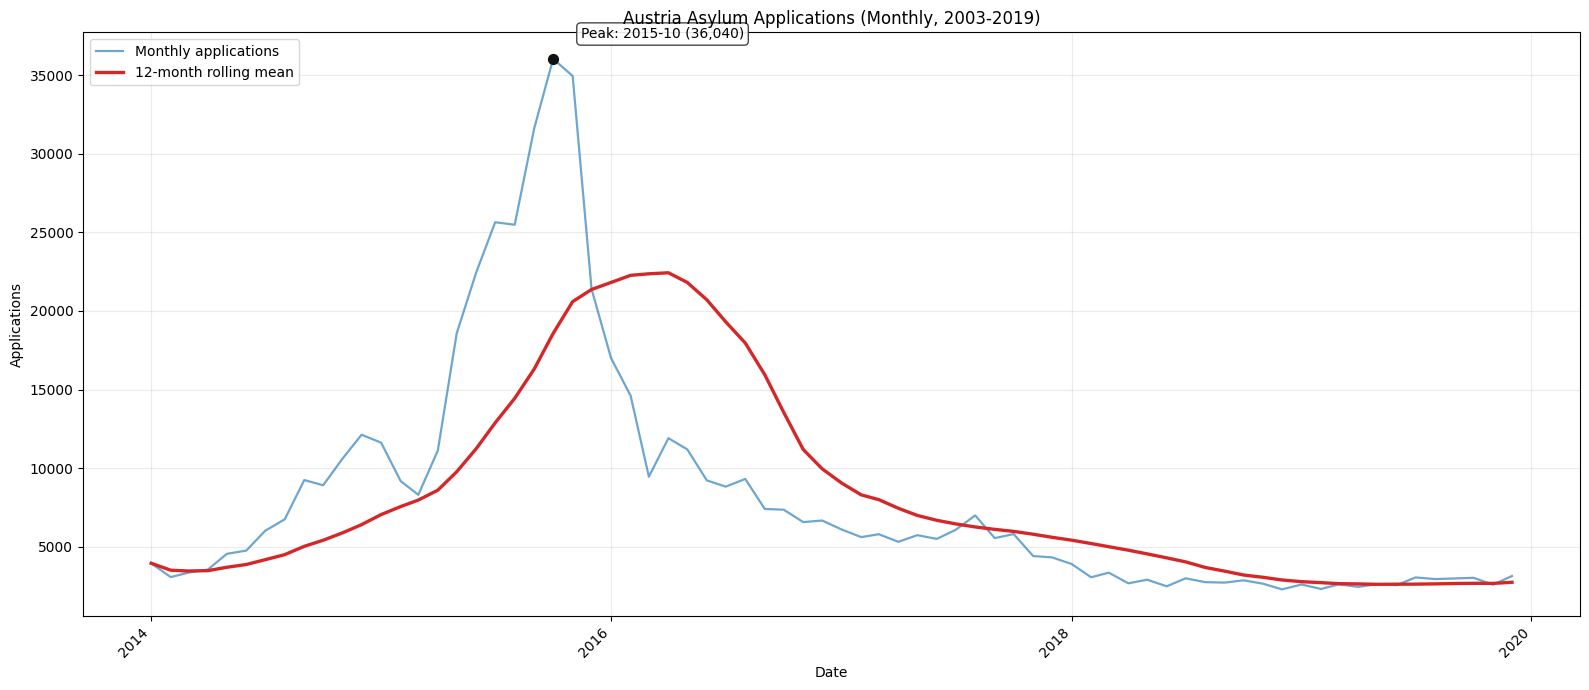

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Reuse in-memory 'out' if available; otherwise load the file produced by Cell 21.
if "out" not in globals() or out is None or out.empty:
    out = pd.read_csv("austria_asylum_monthly.csv", parse_dates=["date"])

plot_df = out.copy().sort_values("date")
plot_df["rolling_12m"] = plot_df["applications_total"].rolling(12, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(
    plot_df["date"],
    plot_df["applications_total"],
    color="#1f77b4",
    linewidth=1.6,
    alpha=0.65,
    label="Monthly applications",
)
ax.plot(
    plot_df["date"],
    plot_df["rolling_12m"],
    color="#d62728",
    linewidth=2.4,
    label="12-month rolling mean",
)

peak_idx = plot_df["applications_total"].idxmax()
peak_date = plot_df.loc[peak_idx, "date"]
peak_val = int(plot_df.loc[peak_idx, "applications_total"])
ax.scatter([peak_date], [peak_val], color="#111111", s=50, zorder=5)
ax.annotate(
    f"Peak: {peak_date.strftime('%Y-%m')} ({peak_val:,})",
    xy=(peak_date, peak_val),
    xytext=(20, 15),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#333", alpha=0.9),
)

ax.set_title("Austria Asylum Applications (Monthly, 2003-2019)")
ax.set_xlabel("Date")
ax.set_ylabel("Applications")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45, ha="right")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

#### 3.3.1 Monthly Crude Oil price

Rows: 276
Date range: 2003-01 -> 2025-12

Head:
      date   WTI_USD  Brent_USD
2003-01-01 32.699047        NaN
2003-02-01 35.733158        NaN
2003-03-01 33.156191        NaN
2003-04-01 28.135714        NaN
2003-05-01 28.070476        NaN
2003-06-01 30.519524        NaN
2003-07-01 30.702273        NaN
2003-08-01 31.597143        NaN


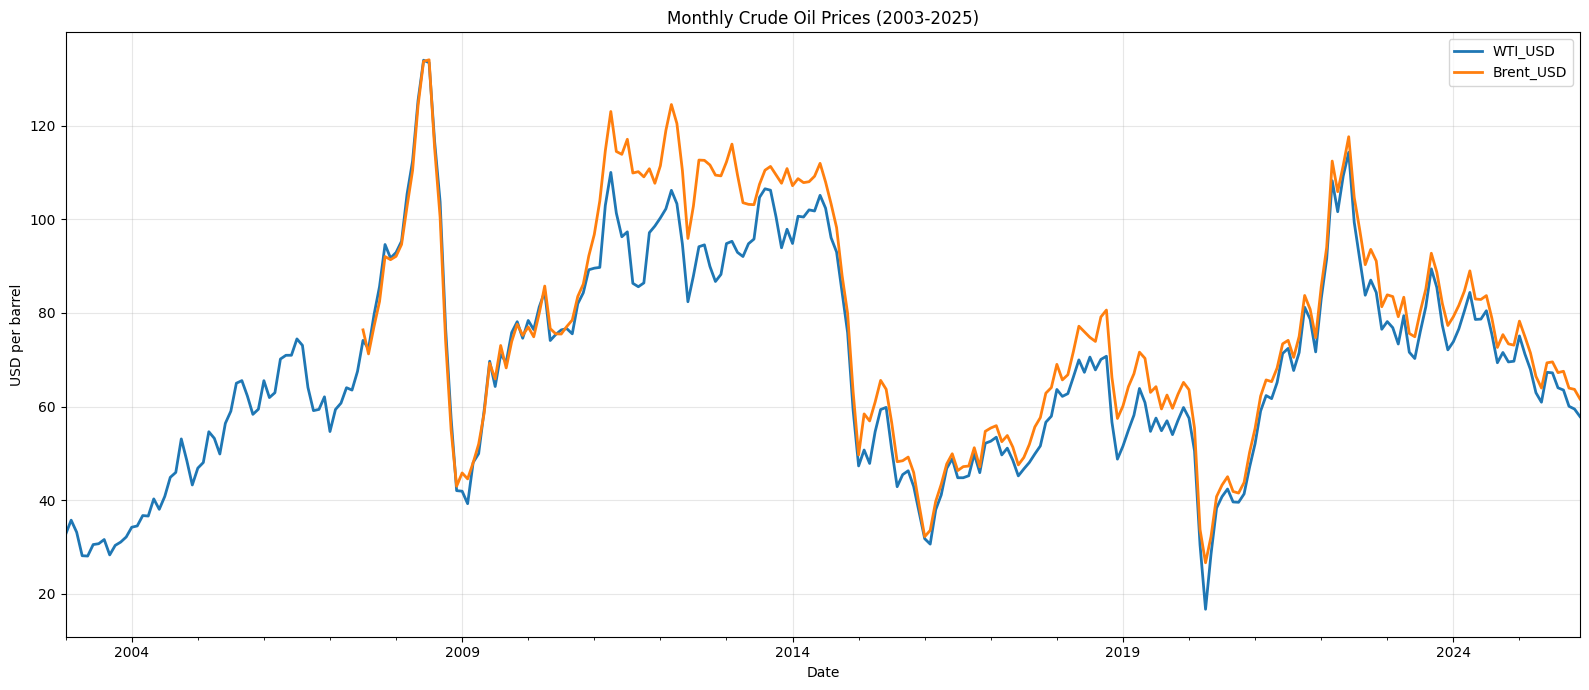

,date,WTI_USD,Brent_USD
0,2003-01-01,32.699047,NaN
1,2003-02-01,35.733158,NaN
2,2003-03-01,33.156191,NaN
3,2003-04-01,28.135714,NaN
4,2003-05-01,28.070476,NaN
...,...,...,...
271,2025-08-01,64.019048,67.261428
272,2025-09-01,63.533809,67.548571
273,2025-10-01,60.069565,63.953913
274,2025-11-01,59.479474,63.679474


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Monthly crude oil prices (USD) from Yahoo Finance futures symbols.
# CL=F: WTI Crude, BZ=F: Brent Crude
START = "2003-01-01"
END = "2025-12-31"
TICKERS = {
    "WTI": "CL=F",
    "Brent": "BZ=F",
}

series = {}
for name, ticker in TICKERS.items():
    px = yf.download(
        ticker,
        start=START,
        end="2026-01-01",  # end is exclusive
        auto_adjust=False,
        progress=False,
    )["Close"]

    if px.empty:
        raise RuntimeError(f"No data returned for {ticker}")

    monthly = px.resample("MS").mean()
    series[name] = monthly

crude_monthly = pd.concat(series, axis=1).reset_index()
crude_monthly.columns = ["date", "WTI_USD", "Brent_USD"]
crude_monthly = crude_monthly[(crude_monthly["date"] >= START) & (crude_monthly["date"] <= END)].copy()

# Save for reuse
crude_monthly.to_csv("monthly_crude_oil_prices_2003_2025.csv", index=False)
crude_monthly.to_excel("monthly_crude_oil_prices_2003_2025.xlsx", index=False)

print(f"Rows: {len(crude_monthly)}")
print(
    f"Date range: {crude_monthly['date'].min().strftime('%Y-%m')} -> "
    f"{crude_monthly['date'].max().strftime('%Y-%m')}"
)
print("\nHead:")
print(crude_monthly.head(8).to_string(index=False))

# Plot
ax = crude_monthly.plot(
    x="date",
    y=["WTI_USD", "Brent_USD"],
    figsize=(16, 7),
    linewidth=2,
)
ax.set_title("Monthly Crude Oil Prices (2003-2025)")
ax.set_xlabel("Date")
ax.set_ylabel("USD per barrel")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

crude_monthly

### 3.4 Kultur

#### 3.4.1 Box office revenues

In [ ]:
"""
Box Office Mojo Daily Box Office Scraper
Scrapes daily box office data for years 2003–2025 and saves to CSV.

NOTE: Box Office Mojo blocks datacenter/server IPs.
URL pattern: https://www.boxofficemojo.com/daily/{year}/?view=year

NOTE: Box Office Mojo blocks datacenter/server IPs.
Run this script on your own computer (not a cloud server).

Requirements:
    pip install requests beautifulsoup4

Usage:
    python boxofficemojo_scraper.py
"""

import csv
import sys
import time
import requests
from bs4 import BeautifulSoup

BASE_URL = "https://www.boxofficemojo.com/daily/{year}/?view=year"
YEARS = list(range(2003, 2026))   # 2003 through 2025
OUTPUT_FILE = "boxofficemojo_daily_2003_2025.csv"
DELAY_SECONDS = 2.0               # Polite delay between requests

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    ),
    "Accept": (
        "text/html,application/xhtml+xml,application/xml;"
        "q=0.9,image/avif,image/webp,*/*;q=0.8"
    ),
    "Accept-Language": "en-US,en;q=0.9",
    "Accept-Encoding": "gzip, deflate, br",
    "Referer": "https://www.boxofficemojo.com/",
    "DNT": "1",
    "Connection": "keep-alive",
    "Upgrade-Insecure-Requests": "1",
}

CSV_COLUMNS = [
    "year",
    "date",
    "day_of_week",
    "day_number",
    "top10_gross",
    "pct_change_yesterday",
    "pct_change_last_week",
    "num_releases",
    "number1_release",
    "number1_gross",
]


def make_session() -> requests.Session:
    """Create a session that mimics a browser visit."""
    session = requests.Session()
    session.headers.update(HEADERS)

    # Visit the homepage first to get cookies (mimics a real browser)
    try:
        print("Warming up session (visiting homepage)...")
        session.get("https://www.boxofficemojo.com/", timeout=30)
        time.sleep(1.5)
    except requests.RequestException as e:
        print(f"  Warning: homepage visit failed ({e}), continuing anyway...")

    return session


def fetch_year(session: requests.Session, year: int) -> list[dict]:
    """Fetch and parse daily box office data for a given year."""
    url = BASE_URL.format(year=year)
    print(f"  [{year}] GET {url} ...", end=" ", flush=True)

    try:
        resp = session.get(url, timeout=30)
        if resp.status_code == 403:
            print("403 Forbidden — Box Office Mojo is blocking server/VPN IPs.")
            print(
                "  Please run this script on your local machine with a "
                "normal home/office internet connection."
            )
            sys.exit(1)
        resp.raise_for_status()
    except requests.RequestException as e:
        print(f"ERROR: {e}")
        return []

    soup = BeautifulSoup(resp.text, "html.parser")

    # Find the data table
    table = soup.find("table")
    if not table:
        print("no table found (page may be empty or layout changed)")
        return []

    tbody = table.find("tbody")
    rows = tbody.find_all("tr") if tbody else table.find_all("tr")[1:]

    rows_data = []
    for row in rows:
        cells = row.find_all("td")
        if len(cells) < 9:
            continue

        def text(idx: int) -> str:
            return cells[idx].get_text(strip=True)

        rows_data.append({
            "year":                 year,
            "date":                 text(0),
            "day_of_week":         text(1),
            "day_number":          text(2),
            "top10_gross":         text(3),
            "pct_change_yesterday": text(4),
            "pct_change_last_week": text(5),
            "num_releases":        text(6),
            "number1_release":     text(7),
            "number1_gross":       text(8),
        })

    print(f"{len(rows_data)} rows")
    return rows_data


def main():
    print("=" * 55)
    print(" Box Office Mojo Daily Scraper  (2003 – 2025)")
    print("=" * 55)
    print()

    session = make_session()
    all_rows: list[dict] = []
    failed_years: list[int] = []

    for i, year in enumerate(YEARS):
        rows = fetch_year(session, year)

        if rows:
            all_rows.extend(rows)
        else:
            failed_years.append(year)

        # Vary the delay slightly to look more human
        if i < len(YEARS) - 1:
            time.sleep(DELAY_SECONDS + (i % 3) * 0.5)

    print()
    print(f"Total rows collected : {len(all_rows)}")
    if failed_years:
        print(f"Failed / empty years : {failed_years}")

    if not all_rows:
        print("No data was collected. Exiting without writing file.")
        sys.exit(1)

    print(f"Writing → {OUTPUT_FILE}")
    with open(OUTPUT_FILE, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=CSV_COLUMNS)
        writer.writeheader()
        writer.writerows(all_rows)

    print(f"Done! {len(all_rows):,} rows saved to '{OUTPUT_FILE}'")


if __name__ == "__main__":
    main()

 Box Office Mojo Daily Scraper  (2003 – 2025)

Warming up session (visiting homepage)...
  [2003] GET https://www.boxofficemojo.com/daily/2003/?view=year ... 365 rows
  [2004] GET https://www.boxofficemojo.com/daily/2004/?view=year ... 366 rows
  [2005] GET https://www.boxofficemojo.com/daily/2005/?view=year ... 365 rows
  [2006] GET https://www.boxofficemojo.com/daily/2006/?view=year ... 365 rows
  [2007] GET https://www.boxofficemojo.com/daily/2007/?view=year ... 365 rows
  [2008] GET https://www.boxofficemojo.com/daily/2008/?view=year ... 366 rows
  [2009] GET https://www.boxofficemojo.com/daily/2009/?view=year ... 365 rows
  [2010] GET https://www.boxofficemojo.com/daily/2010/?view=year ... 365 rows
  [2011] GET https://www.boxofficemojo.com/daily/2011/?view=year ... 365 rows
  [2012] GET https://www.boxofficemojo.com/daily/2012/?view=year ... 366 rows
  [2013] GET https://www.boxofficemojo.com/daily/2013/?view=year ... 365 rows
  [2014] GET https://www.boxofficemojo.com/daily/2014

### 3.5 Panorama

#### 3.5.1 Weather

In [ ]:
"""
GeoSphere Austria Daily Weather Downloader
==========================================
Downloads daily climate station data via the GeoSphere Austria API.

API docs : https://dataset.api.hub.geosphere.at/v1/docs/
Resource : klima-v2-1d  (Weather station daily, CC-BY 4.0)

Requirements:
    pip install requests pandas

Output:
    geosphere_daily_weather.csv
"""

import time
from datetime import datetime

import pandas as pd
import requests

# -- Config --------------------------------------------------------------------
API_BASE = "https://dataset.api.hub.geosphere.at/v1"
RESOURCE = "klima-v2-1d"
START = "2003-01-01"
END = "2025-12-31"
OUTPUT = "geosphere_daily_weather.csv"

# API uses lowercase names for klima-v2-1d.
PARAMETERS = {
    "TM": "tl_mittel",     # mean daily temperature (2m)
    "TX": "tlmax",         # max daily temperature (2m)
    "TN": "tlmin",         # min daily temperature (2m)
    "RR": "rr",            # precipitation sum (mm)
    "SO": "so_h",          # sunshine duration (h)
    "FFAM": "vv_mittel",   # mean wind speed (m/s)
    "RELHUM": "rf_mittel", # relative humidity (%)
    "SCHNEE": "sh",        # snow depth (cm)
}

# Safety controls
CHUNK_YEARS = 5
DELAY_BETWEEN_REQUESTS = 0.25
HOURLY_LIMIT = 220
MAX_RETRIES = 6
MAX_STATIONS = None  # Set e.g. 25 for quick smoke tests.

HEADERS = {"Accept": "application/json"}

# -- Rate limit state -----------------------------------------------------------
_req_times = []


def _prune_req_times(now):
    global _req_times
    _req_times = [t for t in _req_times if now - t < 3600]


def rate_limited_get(url, params=None, timeout=120):
    """GET with pacing + retries for 429/transient errors."""
    global _req_times

    for attempt in range(1, MAX_RETRIES + 1):
        now = time.time()
        _prune_req_times(now)

        if len(_req_times) >= HOURLY_LIMIT:
            wait = 3600 - (now - _req_times[0]) + 1
            print(f"\n  [rate-limit/hour] sleeping {wait:.0f}s", flush=True)
            time.sleep(max(wait, 0))
            now = time.time()
            _prune_req_times(now)

        time.sleep(DELAY_BETWEEN_REQUESTS)

        try:
            r = requests.get(url, params=params, headers=HEADERS, timeout=timeout)
            _req_times.append(time.time())

            if r.status_code == 429:
                retry_after = r.headers.get("Retry-After")
                if retry_after and retry_after.isdigit():
                    wait = int(retry_after)
                else:
                    wait = min(10 * (2 ** (attempt - 1)), 300)
                print(f"\n  [429] attempt {attempt}/{MAX_RETRIES}, waiting {wait}s", flush=True)
                if attempt == MAX_RETRIES:
                    return r
                time.sleep(wait)
                continue

            if 500 <= r.status_code < 600:
                wait = min(5 * (2 ** (attempt - 1)), 120)
                print(f"\n  [HTTP {r.status_code}] retry in {wait}s", flush=True)
                if attempt == MAX_RETRIES:
                    return r
                time.sleep(wait)
                continue

            return r

        except (requests.exceptions.Timeout, requests.exceptions.ConnectionError) as e:
            wait = min(5 * (2 ** (attempt - 1)), 120)
            print(f"\n  [network] {e} -> retry in {wait}s", flush=True)
            if attempt == MAX_RETRIES:
                raise
            time.sleep(wait)

    raise RuntimeError("rate_limited_get exhausted retries")


def get_metadata():
    url = f"{API_BASE}/station/historical/{RESOURCE}/metadata"
    r = rate_limited_get(url, timeout=60)
    r.raise_for_status()
    return r.json()


def get_stations(meta):
    stations = meta.get("stations", [])
    if MAX_STATIONS is not None:
        stations = stations[:MAX_STATIONS]
    print(f"  {len(stations)} stations selected")
    return stations


def validate_parameters(meta):
    available = {p.get("name") for p in meta.get("parameters", []) if isinstance(p, dict)}
    requested = set(PARAMETERS.values())
    missing = sorted(requested - available)
    if missing:
        raise RuntimeError("Parameter(s) unavailable: " + ", ".join(missing))


def year_chunks(start_str, end_str, chunk=CHUNK_YEARS):
    sy = int(start_str[:4])
    ey = int(end_str[:4])
    y = sy
    while y <= ey:
        yield f"{y}-01-01", f"{min(y + chunk - 1, ey)}-12-31"
        y += chunk


def request_size(n_params, start, end):
    days = (datetime.fromisoformat(end) - datetime.fromisoformat(start)).days + 1
    return n_params * days


def fetch_chunk(station_id, chunk_start, chunk_end):
    size = request_size(len(PARAMETERS), chunk_start, chunk_end)
    if size > 900_000:
        print(f"  [skip] est size {size:,} too large for {station_id} {chunk_start}..{chunk_end}")
        return []

    url = f"{API_BASE}/station/historical/{RESOURCE}"
    params = {
        "parameters": ",".join(PARAMETERS.values()),
        "station_ids": station_id,
        "start": chunk_start,
        "end": chunk_end,
        "output_format": "geojson",
    }

    r = rate_limited_get(url, params=params, timeout=120)
    if r.status_code in (404, 204):
        return []
    if r.status_code != 200:
        print(f"  [HTTP {r.status_code}] station {station_id} {chunk_start}..{chunk_end}")
        return []

    data = r.json()
    features = data.get("features", [])
    timestamps = data.get("timestamps", [])
    if not features or not timestamps:
        return []

    feature = features[0]
    props = feature.get("properties", {})
    coords = feature.get("geometry", {}).get("coordinates", [None, None, None])

    meta = {
        "station_id": station_id,
        "station_name": props.get("name", ""),
        "lon": coords[0] if len(coords) > 0 else None,
        "lat": coords[1] if len(coords) > 1 else None,
        "altitude_m": coords[2] if len(coords) > 2 else None,
    }

    param_data = {
        alias: props.get("parameters", {}).get(api_name, {}).get("data", [])
        for alias, api_name in PARAMETERS.items()
    }

    rows = []
    for i, ts in enumerate(timestamps):
        row = {"date": ts[:10], **meta}
        for alias in PARAMETERS.keys():
            vals = param_data[alias]
            row[alias] = vals[i] if i < len(vals) else None
        rows.append(row)
    return rows


# -- Main ----------------------------------------------------------------------
def main():
    global _req_times
    _req_times = []  # Reset notebook state across reruns.

    print("GeoSphere Austria - Daily Weather Download")
    print(f"Resource   : {RESOURCE}")
    print(f"Period     : {START} -> {END}")
    print(f"Parameters : {', '.join(PARAMETERS.keys())}")
    print(f"Station cap: {MAX_STATIONS if MAX_STATIONS is not None else 'all'}")
    print("=" * 60)

    print("\nFetching metadata...")
    meta = get_metadata()
    validate_parameters(meta)

    print("Fetching station list...")
    stations = get_stations(meta)

    all_rows = []
    total = len(stations)

    for i, station in enumerate(stations, start=1):
        sid = station["id"]
        name = station.get("name", str(sid))
        print(f"  [{i:4d}/{total}] {sid:>6} {name[:28]:<28}", end="", flush=True)

        station_rows = []
        for chunk_start, chunk_end in year_chunks(START, END):
            station_rows.extend(fetch_chunk(sid, chunk_start, chunk_end))

        all_rows.extend(station_rows)
        print(f" {len(station_rows):5d} rows")

    print(f"\nTotal rows collected: {len(all_rows):,}")
    if not all_rows:
        raise RuntimeError("No data downloaded.")

    df = pd.DataFrame(all_rows)
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["station_id", "date"]).reset_index(drop=True)

    df.to_csv(OUTPUT, index=False, encoding="utf-8-sig")
    print(f"Saved -> {OUTPUT}")
    print(f"Stations  : {df['station_id'].nunique()}")
    print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")
    print(f"Shape     : {df.shape}")
    print(df.head(3).to_string())


RUN_MAIN = True  # Set True to run full download.
if __name__ == "__main__" and RUN_MAIN:
    main()

GeoSphere Austria - Daily Weather Download
Resource   : klima-v2-1d
Period     : 2003-01-01 -> 2025-12-31
Parameters : TM, TX, TN, RR, SO, FFAM, RELHUM, SCHNEE
Station cap: all

Fetching metadata...

  [429] attempt 1/6, waiting 1488s


KeyboardInterrupt: 

### 3.6 Sport

### 3.7 Web

### 3.8 Wirtschaft

### 3.9 Wissenschaft